# RNN vs LSTM demo

This notebook shows a toy example for which the RNN fails due to vanishing gradients.

Tasks:

1. Skim and run the notebook in default settings. Confirm that you understood the code by discussing these questions with your partner:
    1. How is the dataset constructed? What is predicted?
    1. How is the model set up?
    2. What is the loss?
    3. What is the method to minimize the loss?
    4. What evaluation metrics are used?
2. Investigate: For which $T$ does which model work?
3. Try: What other hyperparameters could you tune to make the RNN work?
4. Bonus: Run the optional cell at the bottom to see at which point in time the RNN loses the information.

## Dataset

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
torch.manual_seed(0)
random.seed(0)
device = 'cpu'

if "models" not in locals():
    models = {}
if "histories" not in locals():
    histories = {}
if "probe_results" not in locals():
    probe_results = {}

EPOCHS = 2000
BATCH_SIZE = 64
VAL_BATCH_SIZE = 2048
HIDDEN_DIM = 32
LR = 1e-3
EVAL_EVERY = 100

def make_batch(batch_size, T):
    bits = torch.randint(0, 2, (batch_size, 1), device=device).float()
    noise = torch.randn(batch_size, T, device=device)
    x = torch.cat([bits, noise], dim=1).unsqueeze(-1)
    y = bits.squeeze(-1)
    return x, y

device=cpu, trained Ts=[2, 10, 15, 18, 20, 100]
Edit T and rerun the training cell to add another sequence length.


In [ ]:
# Modify T and rerun this and the following cells
# to train a model on a different sequence length.
T = 10

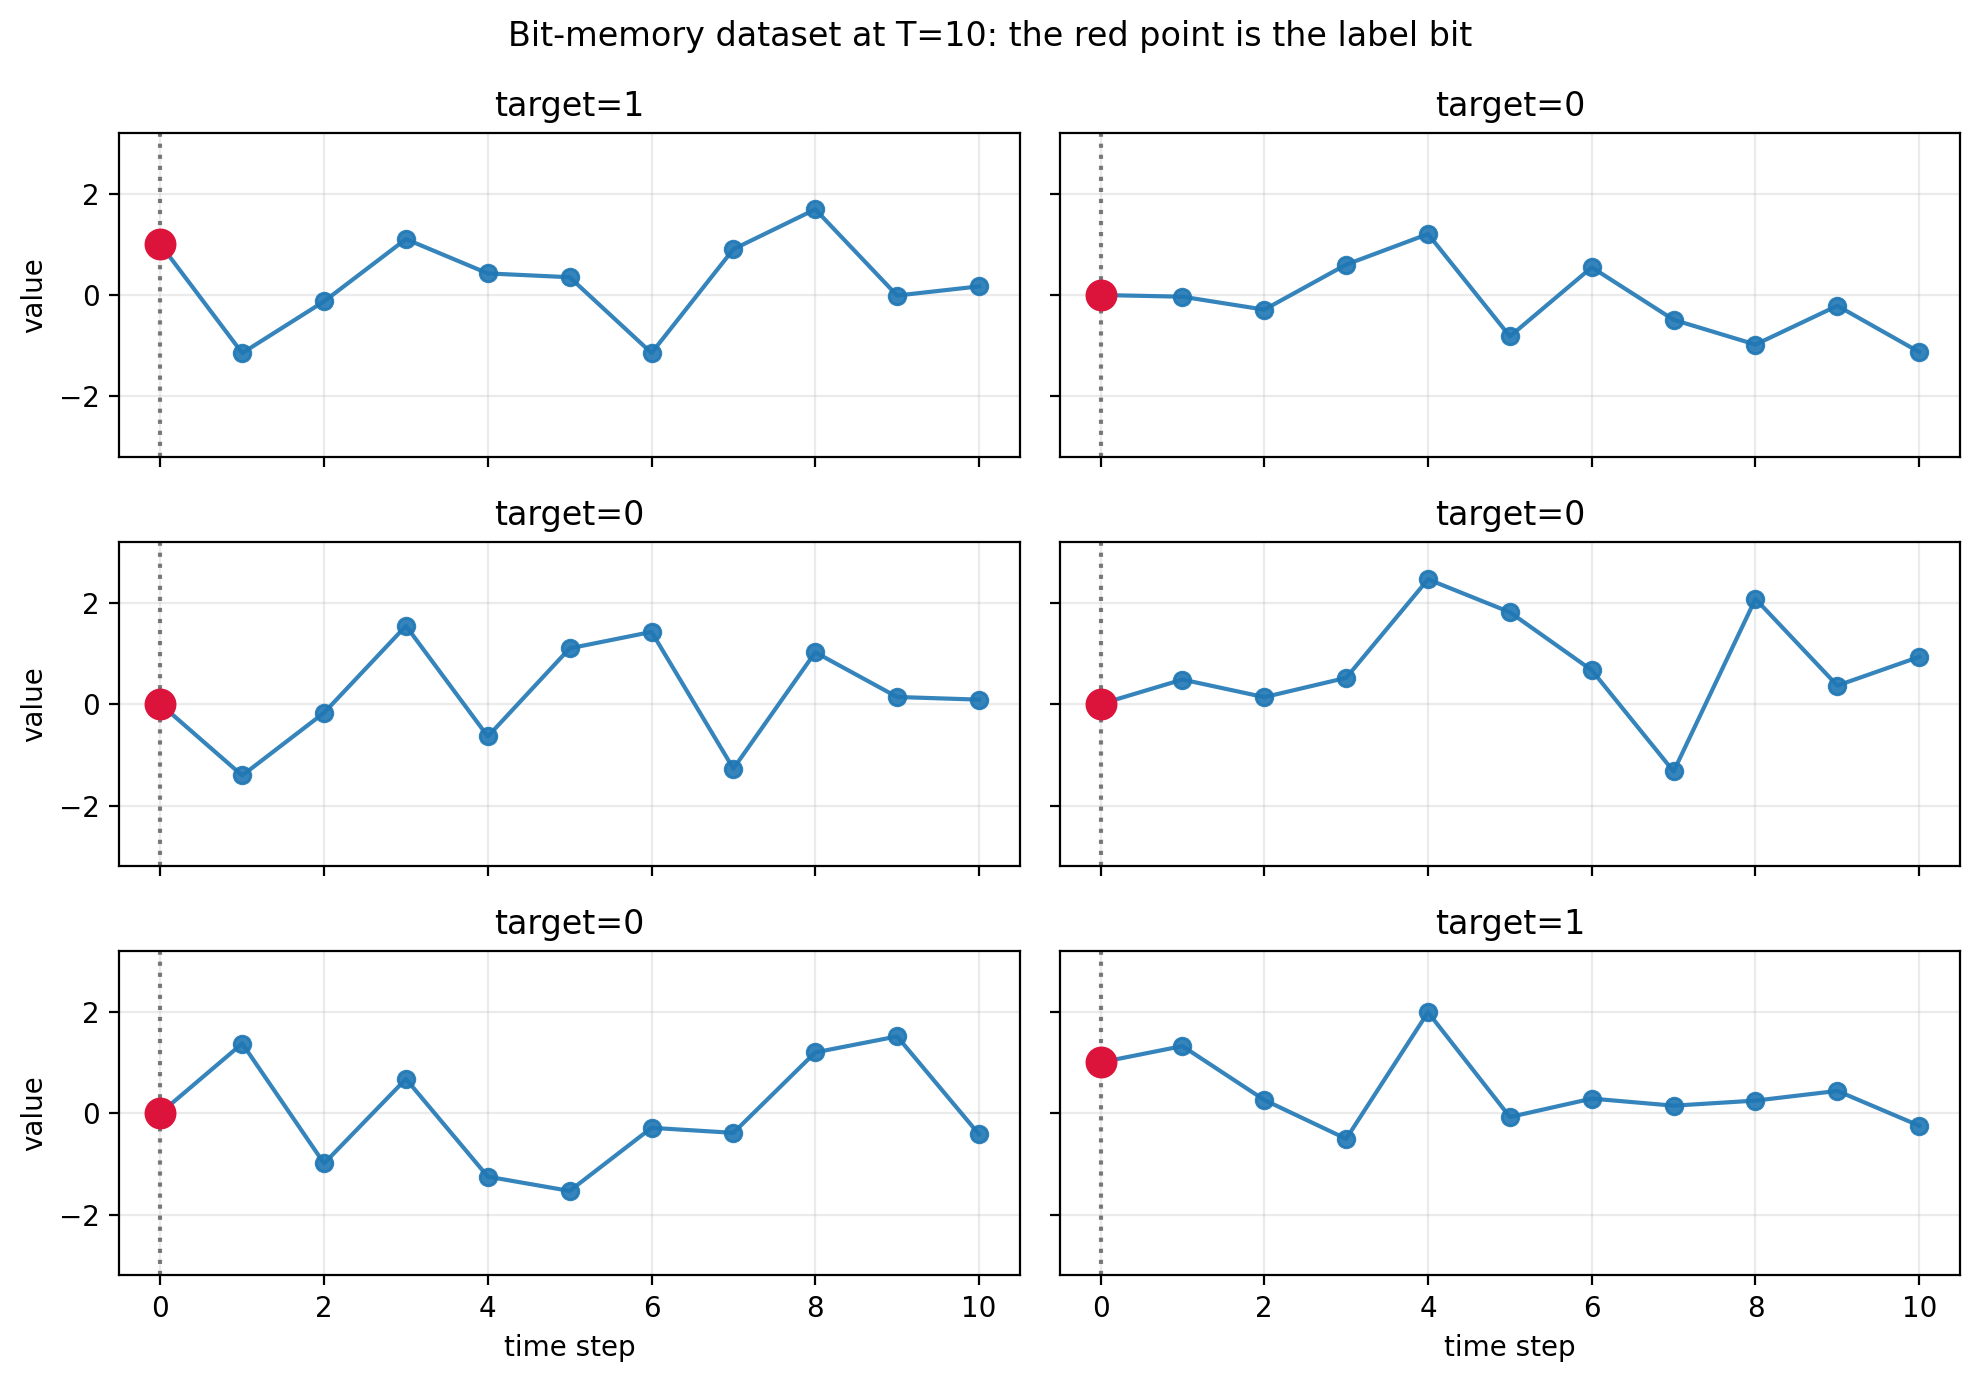

In [ ]:
# Visualize the dataset for the current T
x_demo, y_demo = make_batch(6, T)
time = torch.arange(T + 1).cpu().numpy()
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, sample, label in zip(axes.flat, x_demo.squeeze(-1).cpu(), y_demo.cpu()):
    ax.plot(time, sample.numpy(), marker="o", lw=1.5, alpha=0.9)
    ax.scatter([0], [sample[0].item()], s=110, color="crimson", zorder=3)
    ax.axvline(0, color="black", ls=":", alpha=0.5)
    ax.set_title(f"target={int(label.item())}")
    ax.set_ylim(-3.2, 3.2)
    ax.grid(alpha=0.25)

for ax in axes[:, 0]:
    ax.set_ylabel("value")
for ax in axes[-1, :]:
    ax.set_xlabel("time step")

fig.suptitle(f"Bit-memory dataset at T={T}: the red point is the label bit")
plt.tight_layout()
plt.show()

## Model

In [ ]:
class BitMemoryModel(nn.Module):
    """
    A simple RNN/LSTM-based model for the bit-memory task.

        The model consists of a recurrent layer (RNN or LSTM)
        followed by a linear head to make the prediction.
    """
    def __init__(self, kind, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.kind = kind
        cell = {"rnn": nn.RNN, "lstm": nn.LSTM}[kind]
        self.rec = cell(1, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, 1)
        if kind == "lstm":
            # LSTM: PyTorch initializes the forget gate bias to 0.0 by default,
            # which turns off long-term memory at the start of training.
            # We set the forget gate bias to 1.0
            for name, parameter in self.rec.named_parameters():
                if "bias" in name:
                    size = parameter.size(0)
                    with torch.no_grad():
                        parameter.zero_()
                        parameter[size // 4 : size // 2].fill_(1.0)

    def forward(self, x):
        out, _ = self.rec(x)
        return self.head(out[:, -1]).squeeze(-1)

## Train

In [ ]:
# Rerun this cell to train new models on the current T (or after modifying other hyperparameters)

loss_fn = nn.BCEWithLogitsLoss()

@torch.no_grad()
def evaluate_model(model, T, batch_size=VAL_BATCH_SIZE):
    model.eval()
    x_val, y_val = make_batch(batch_size, T)
    logits = model(x_val)
    loss = loss_fn(logits, y_val).item()
    acc = ((logits.sigmoid() > 0.5).float() == y_val).float().mean().item()
    return loss, acc

def train_pair(T, epochs=EPOCHS, batch_size=BATCH_SIZE, hidden_dim=HIDDEN_DIM, lr=LR, eval_every=EVAL_EVERY):
    run_models = {}
    run_histories = {}

    for kind in ["rnn", "lstm"]:
        model = BitMemoryModel(kind, hidden_dim=hidden_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": []}

        for epoch in range(1, epochs + 1):
            model.train()
            x_train, y_train = make_batch(batch_size, T)
            logits = model(x_train)
            loss = loss_fn(logits, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if epoch == 1 or epoch % eval_every == 0 or epoch == epochs:
                val_loss, val_acc = evaluate_model(model, T)
                history["epoch"].append(epoch)
                history["train_loss"].append(loss.item())
                history["val_loss"].append(val_loss)
                history["val_acc"].append(val_acc)

        run_models[kind] = model.eval()
        run_histories[kind] = history

    models[T] = run_models
    histories[T] = run_histories
    return run_models, run_histories

trained_models, trained_history = train_pair(T)
for kind in ["rnn", "lstm"]:
    print(f"T={T:>3} | {kind.upper():<4} | final val acc={trained_history[kind]['val_acc'][-1]:.3f}")

T= 10 | RNN  | final val acc=1.000
T= 10 | LSTM | final val acc=1.000


## Evaluate

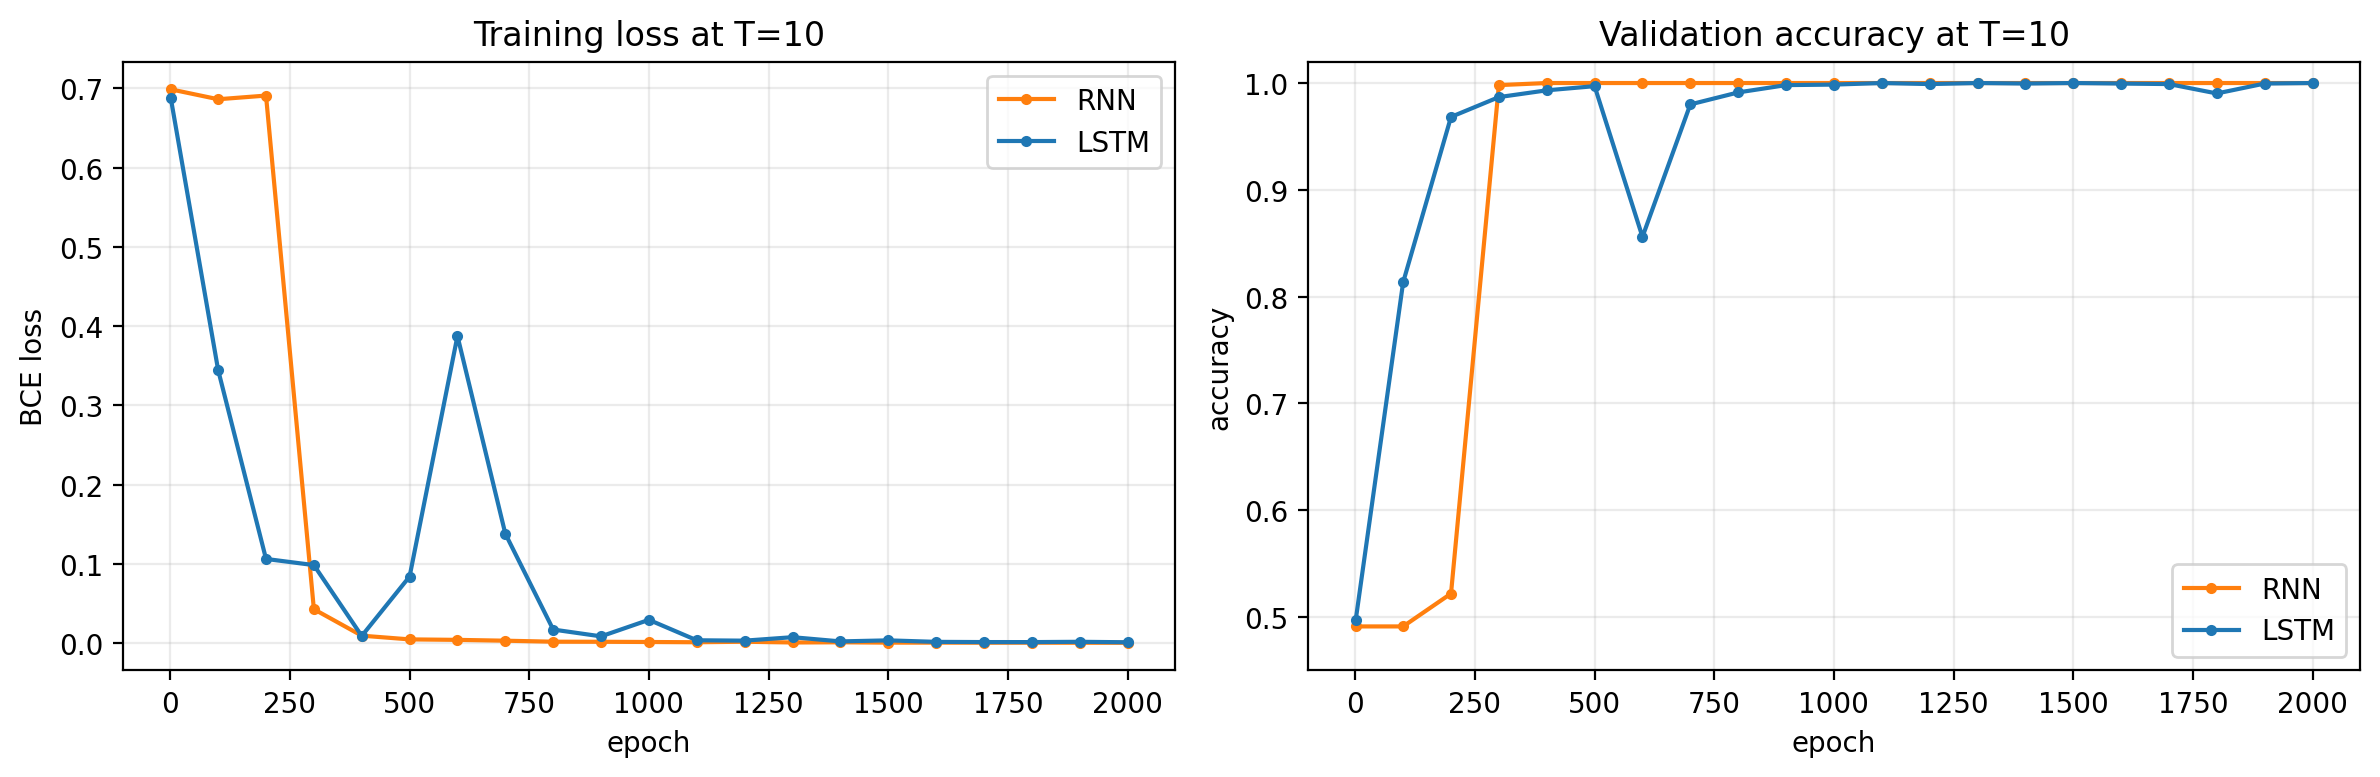

RNN: val loss=0.000, val acc=1.000
LSTM: val loss=0.001, val acc=1.000


In [47]:
history = histories[T]
colors = {"rnn": "tab:orange", "lstm": "tab:blue"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for kind in ["rnn", "lstm"]:
    epochs = history[kind]["epoch"]
    axes[0].plot(epochs, history[kind]["train_loss"], marker="o", ms=3, label=kind.upper(), color=colors[kind])
    axes[1].plot(epochs, history[kind]["val_acc"], marker="o", ms=3, label=kind.upper(), color=colors[kind])

axes[0].set_title(f"Training loss at T={T}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].grid(alpha=0.25)

axes[1].set_title(f"Validation accuracy at T={T}")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

for kind in ["rnn", "lstm"]:
    final_loss = history[kind]["val_loss"][-1]
    final_acc = history[kind]["val_acc"][-1]
    print(f"{kind.upper()}: val loss={final_loss:.3f}, val acc={final_acc:.3f}")

### Accuracy over T

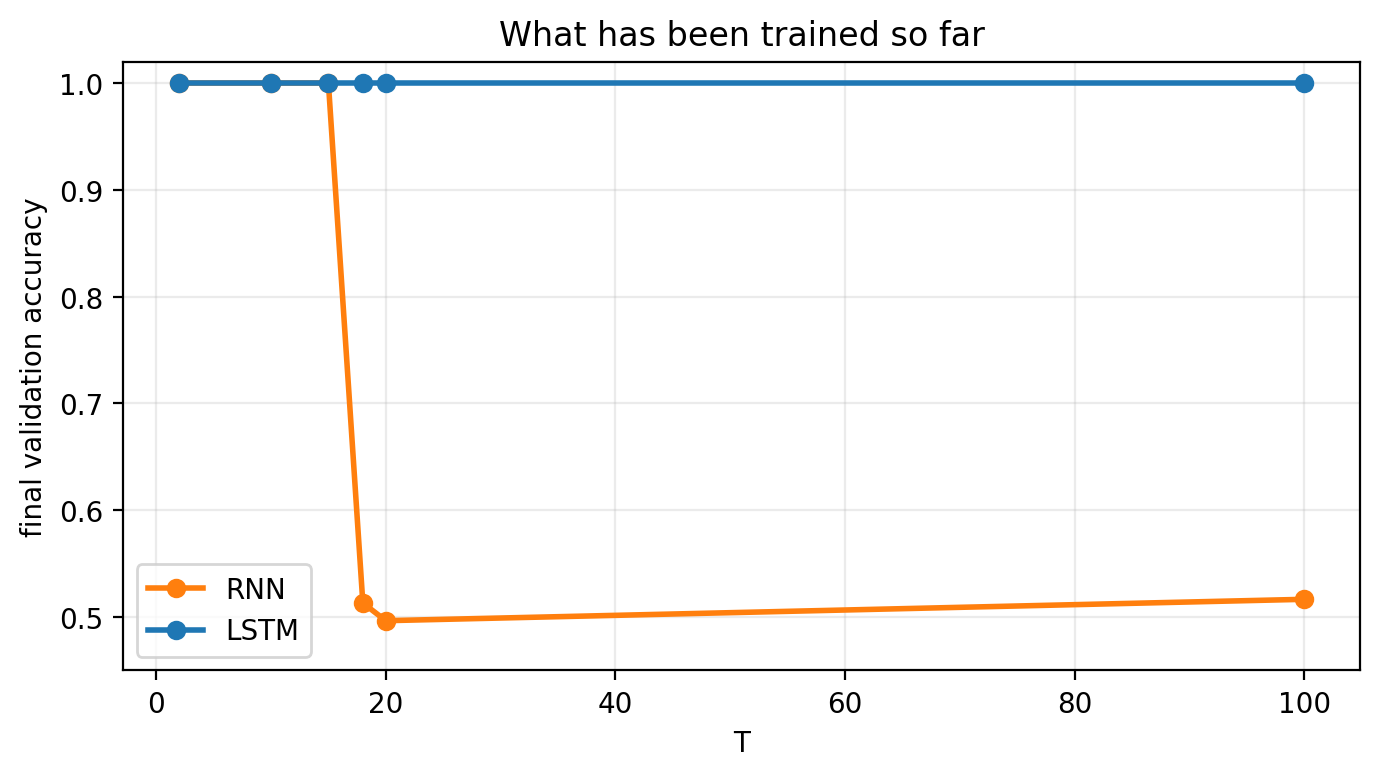

T=  2 | RNN=1.000 | LSTM=1.000
T= 10 | RNN=1.000 | LSTM=1.000
T= 15 | RNN=1.000 | LSTM=1.000
T= 18 | RNN=0.513 | LSTM=1.000
T= 20 | RNN=0.497 | LSTM=1.000
T=100 | RNN=0.517 | LSTM=1.000


In [40]:
trained_Ts = sorted(histories)
if not trained_Ts:
    raise RuntimeError("Train at least one T first.")

fig, ax = plt.subplots(figsize=(7, 4))
for kind, color in [("rnn", "tab:orange"), ("lstm", "tab:blue")]:
    values = [histories[t][kind]["val_acc"][-1] for t in trained_Ts]
    ax.plot(trained_Ts, values, marker="o", lw=2, label=kind.upper(), color=color)

ax.set_xlabel("T")
ax.set_ylabel("final validation accuracy")
ax.set_ylim(0.45, 1.02)
ax.set_title("What has been trained so far")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

for t in trained_Ts:
    print(
        f"T={t:>3} | RNN={histories[t]['rnn']['val_acc'][-1]:.3f} | LSTM={histories[t]['lstm']['val_acc'][-1]:.3f}"
    )

### Bonus: Model inspection

Skip this when running the notebook for the first time.

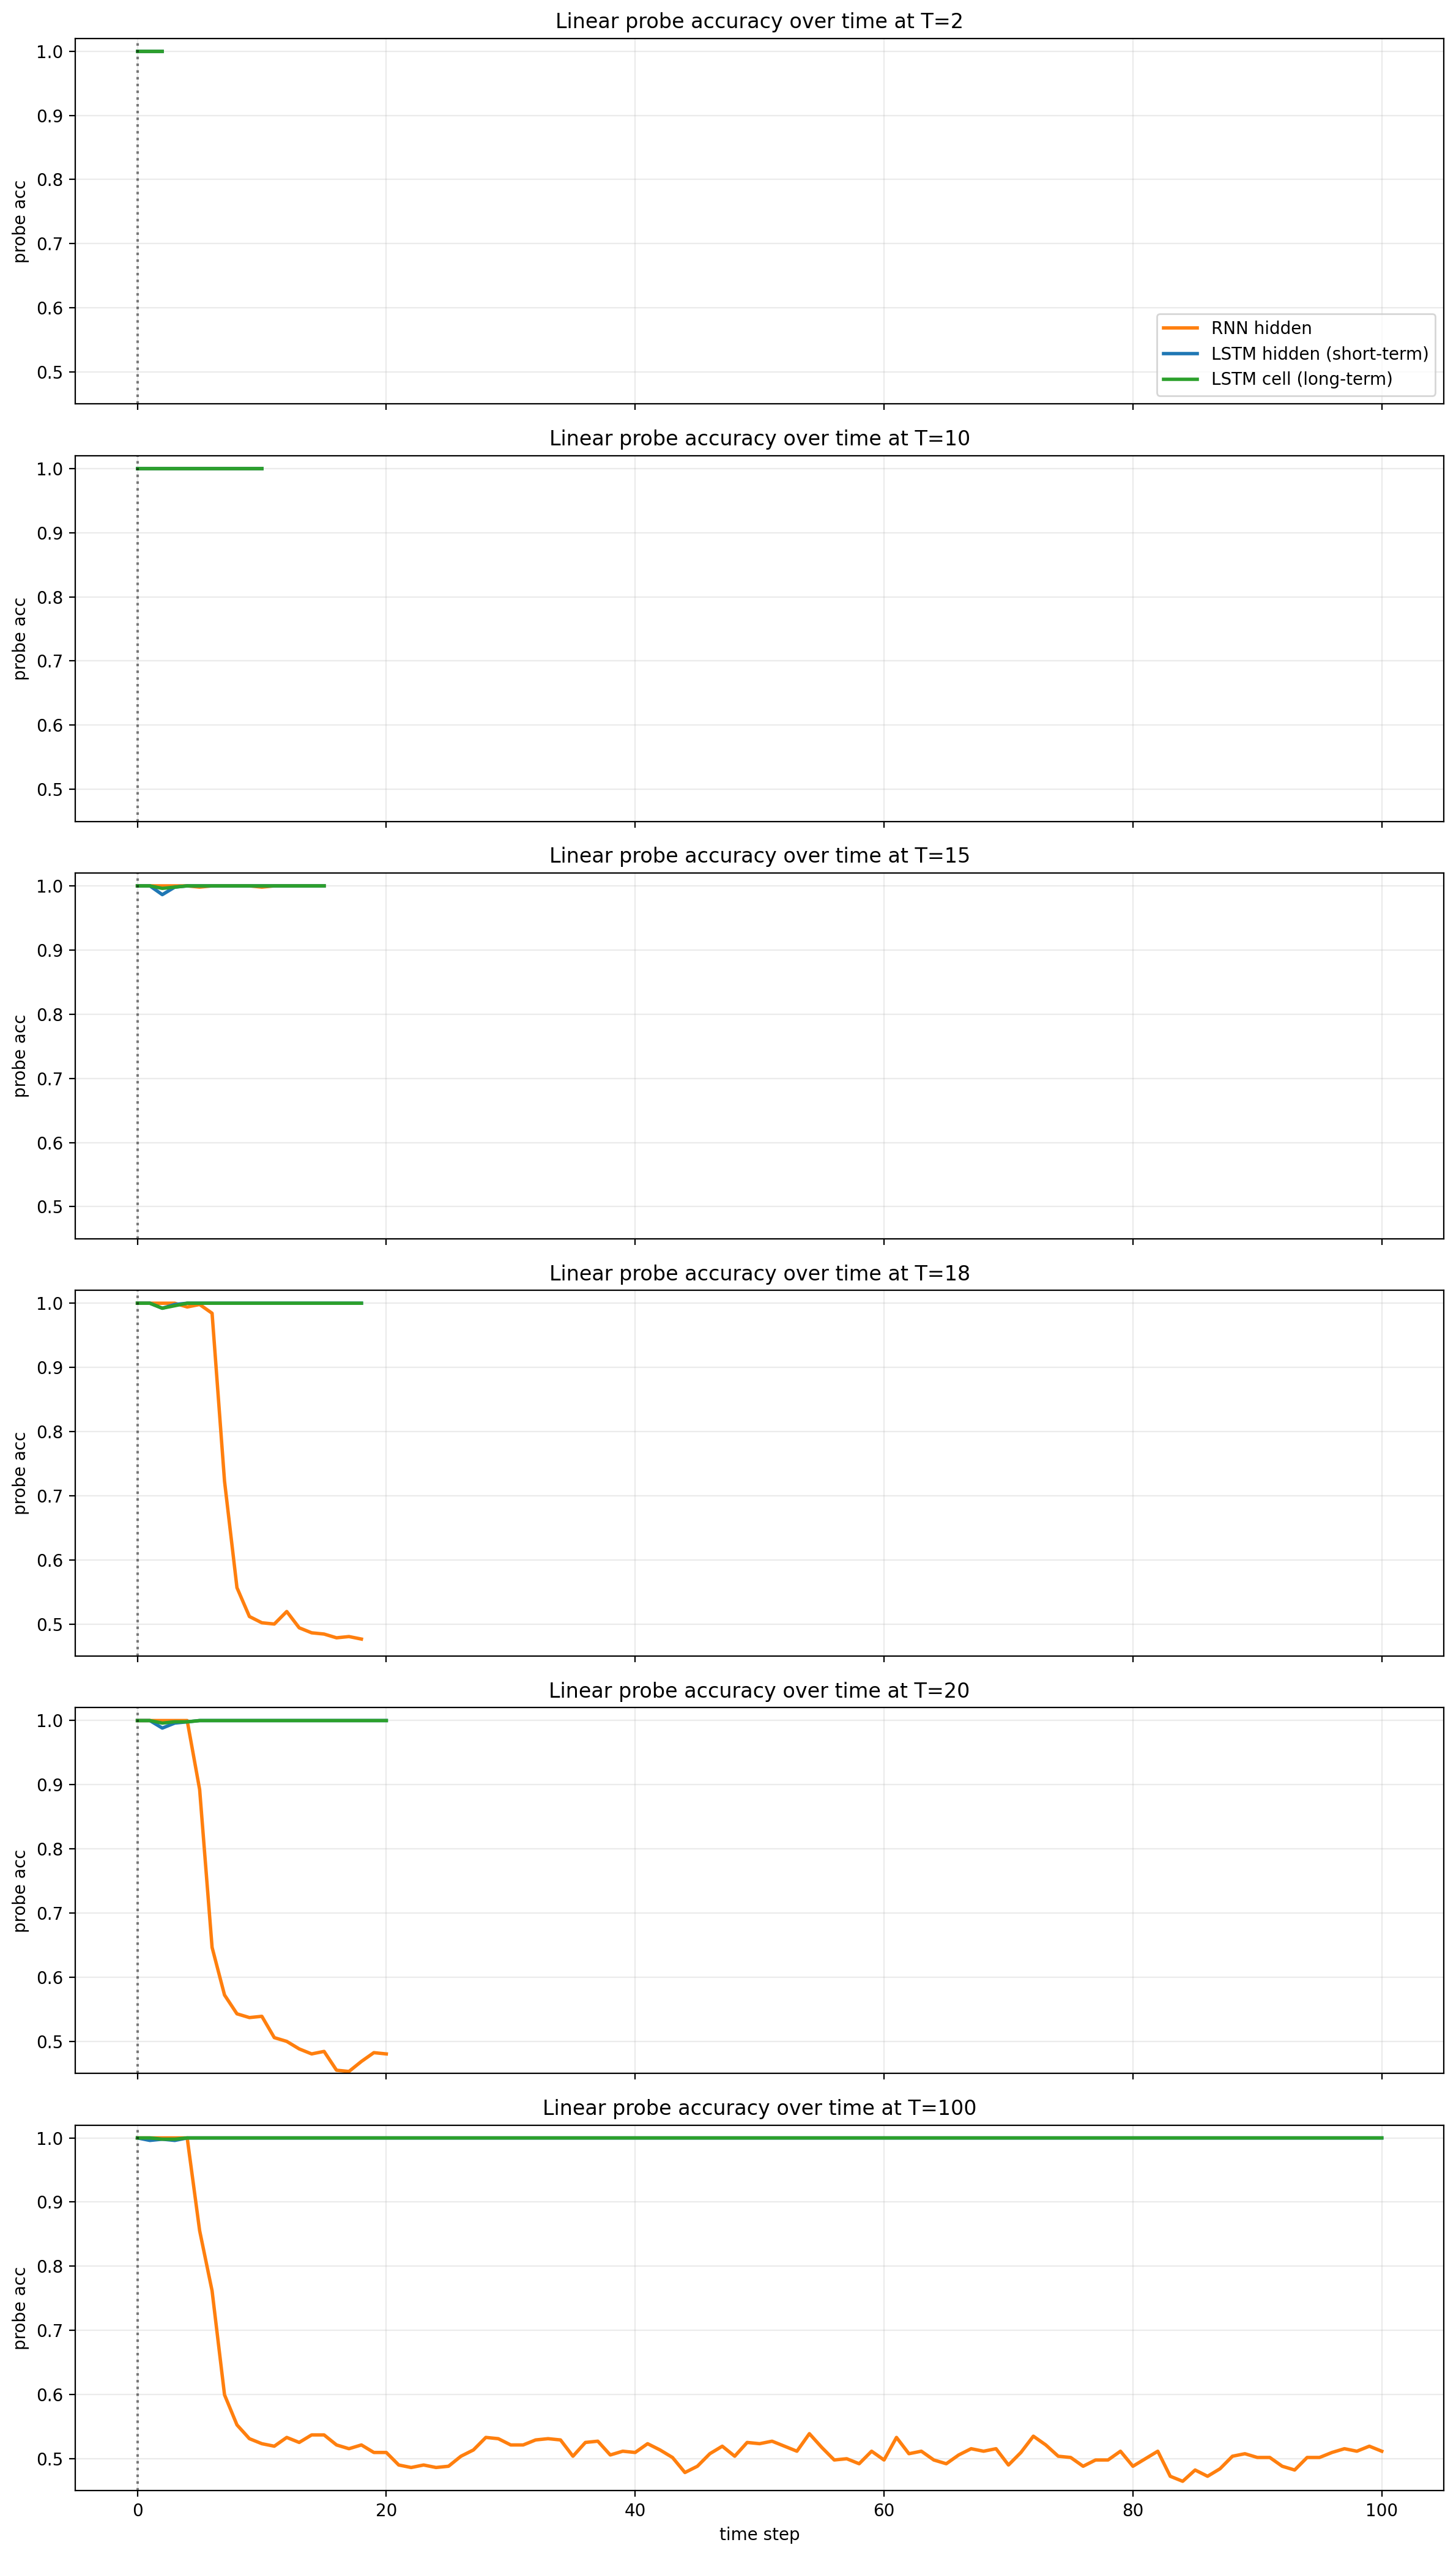

In [48]:
if "probe_results" not in locals():
    probe_results = {}

class TimeProbe(nn.Module):
    def __init__(self, steps, hidden_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(steps, hidden_dim))
        self.bias = nn.Parameter(torch.zeros(steps))

    def forward(self, features):
        return (features * self.weight.unsqueeze(0)).sum(dim=-1) + self.bias.unsqueeze(0)

@torch.no_grad()
def rnn_hidden_trace(model, x):
    out, _ = model.rec(x)
    return out

@torch.no_grad()
def lstm_hidden_cell_trace(model, x):
    rec = model.rec
    probe_cell = nn.LSTMCell(rec.input_size, rec.hidden_size).to(x.device)
    probe_cell.weight_ih.copy_(rec.weight_ih_l0)
    probe_cell.weight_hh.copy_(rec.weight_hh_l0)
    probe_cell.bias_ih.copy_(rec.bias_ih_l0)
    probe_cell.bias_hh.copy_(rec.bias_hh_l0)

    batch_size, steps, _ = x.shape
    h = torch.zeros(batch_size, rec.hidden_size, device=x.device)
    c = torch.zeros(batch_size, rec.hidden_size, device=x.device)
    h_seq = []
    c_seq = []
    for t in range(steps):
        h, c = probe_cell(x[:, t], (h, c))
        h_seq.append(h)
        c_seq.append(c)
    return torch.stack(h_seq, dim=1), torch.stack(c_seq, dim=1)

def train_time_probe(features_train, y_train, features_test, y_test, steps=200, lr=5e-2):
    probe = TimeProbe(features_train.size(1), features_train.size(2)).to(features_train.device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    train_targets = y_train[:, None].expand(-1, features_train.size(1))
    test_targets = y_test[:, None].expand(-1, features_test.size(1))

    for _ in range(steps):
        logits = probe(features_train)
        loss = loss_fn(logits, train_targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        logits_test = probe(features_test)
        acc_test = ((logits_test.sigmoid() > 0.5).float() == test_targets).float().mean(dim=0)
    return acc_test.cpu()

def inspect_models_at_T(T, probe_batch=512, probe_steps=200):
    x_train, y_train = make_batch(probe_batch, T)
    x_test, y_test = make_batch(probe_batch, T)
    out = {}

    rnn_model = models[T]["rnn"]
    rnn_train_h = rnn_hidden_trace(rnn_model, x_train)
    rnn_test_h = rnn_hidden_trace(rnn_model, x_test)
    out[("rnn", "hidden")] = train_time_probe(rnn_train_h, y_train, rnn_test_h, y_test, steps=probe_steps)

    lstm_model = models[T]["lstm"]
    lstm_train_h, lstm_train_c = lstm_hidden_cell_trace(lstm_model, x_train)
    lstm_test_h, lstm_test_c = lstm_hidden_cell_trace(lstm_model, x_test)
    out[("lstm", "hidden")] = train_time_probe(lstm_train_h, y_train, lstm_test_h, y_test, steps=probe_steps)
    out[("lstm", "cell")] = train_time_probe(lstm_train_c, y_train, lstm_test_c, y_test, steps=probe_steps)
    return out

trained_Ts = sorted(models)
if not trained_Ts:
    raise RuntimeError("Train at least one T first.")

for trained_T in trained_Ts:
    if trained_T not in probe_results:
        probe_results[trained_T] = inspect_models_at_T(trained_T)

fig, axes = plt.subplots(len(trained_Ts), 1, figsize=(12, 3.5 * len(trained_Ts)),
                         sharey=True, sharex=True)
if len(trained_Ts) == 1:
    axes = [axes]

for ax, trained_T in zip(axes, trained_Ts):
    row = probe_results[trained_T]
    time = torch.arange(trained_T + 1).cpu().numpy()
    ax.plot(time, row[("rnn", "hidden")].numpy(), lw=2, color="tab:orange", label="RNN hidden")
    ax.plot(time, row[("lstm", "hidden")].numpy(), lw=2, color="tab:blue", label="LSTM hidden (short-term)")
    ax.plot(time, row[("lstm", "cell")].numpy(), lw=2, color="tab:green", label="LSTM cell (long-term)")
    ax.axvline(0, color="black", ls=":", alpha=0.5)
    ax.set_title(f"Linear probe accuracy over time at T={trained_T}")
    ax.set_ylabel("probe acc")
    ax.set_ylim(0.45, 1.02)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("time step")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()